## Digital Finance, Forecasting & Analytics Platform
## Module 4 — Advanced FP&A: Forecast + Budget vs Actuals
### 4.6 ML Revenue Forecast: Driver-Based Ensemble

This section (4.6) extends the forecasting architecture of the Digital Finance, Forecasting & Analytics Platform with a **Machine Learning-based revenue forecasting layer**, designed to complement the statistical SARIMA framework developed in Section 4.2.

Where SARIMA captures **temporal patterns** from the univariate revenue series, the ML ensemble operates from a fundamentally different perspective: it learns revenue behavior directly from **operational business drivers** — prices, unit volumes, channel mix, and product mix.

| Dimension | SARIMA (4.2) | ML Ensemble (4.6) |
|---|---|---|
| Input | Revenue time series only | Price × Volume × Channel × Product drivers |
| Modeling logic | Temporal autocorrelation | Driver-based nonlinear relationships |
| Interpretability | ACF / PACF structure | Feature importance / driver attribution |
| FP&A value | Forecast trajectory | Revenue decomposition + sensitivity analysis |

The two approaches are **complementary** — not competing. SARIMA answers *when* revenue happens; the ML ensemble answers *why* it happens. Together they constitute a more robust forecasting governance framework.

Together, **Modules 4.2 and 4.6** form a complete FP&A intelligence engine — statistical time-series governance anchored by driver-based machine learning attribution.

## 1. Setup & Imports

### 1.1 Imports

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

### 1.2 Visualization Setup

In [36]:
sns.set_style('darkgrid')
palette = sns.color_palette('deep')

### 1.3 Load Dataset

In [37]:
df = pd.read_csv('reg.csv')
df.head()

,datekey,Revenue,Marketing,price_D_A,price_D_E,price_D_I,price_O_A,price_O_E,price_O_I,price_R_A,...,price_R_I,units_D_A,units_D_E,units_D_I,units_O_A,units_O_E,units_O_I,units_R_A,units_R_E,units_R_I
0,201001,954.07,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,265.0,7.0,147.0,14.0,12.0,3.0,309.0,151.0,53.0
1,201002,1033.57,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,287.0,7.0,159.0,16.0,13.0,4.0,335.0,164.0,58.0
2,201003,1351.59,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,375.0,9.0,208.0,20.0,17.0,5.0,438.0,214.0,76.0
3,201004,1272.08,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,353.0,9.0,196.0,19.0,16.0,4.0,412.0,202.0,71.0
4,201005,1431.08,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,397.0,10.0,220.0,22.0,18.0,5.0,463.0,227.0,80.0


## 2. Feature Engineering

ML models do not inherently understand temporal order — they require features that explicitly encode the information SARIMA captures implicitly through autocorrelation structure. The feature set is organized in three layers:

**Temporal features** — encode seasonality and calendar position:
- `year`, `month`: raw calendar coordinates
- `month_sin`, `month_cos`: Fourier encoding of the 12-month seasonal cycle, preventing the model from treating December → January as a large discontinuity in the feature space

**Regime feature** — encodes the structural break observed in the data:
- `is_stress`: binary flag for the 2018–2019 operational stress period, allowing models to learn differential behavior during crisis versus recovery regimes

**Lag features** — encode recent revenue momentum (the temporal memory the model needs):
- `rev_lag1`: prior month revenue — short-term momentum signal
- `rev_lag12`: same month prior year — annual seasonal anchor
- `rev_yoy`: year-over-year revenue growth rate

**Driver features** — the core ML advantage over SARIMA:
- 9 price variables: `price_{channel}_{product}` across Direct, Online, Retail × Automotive, Electric, Industrial
- 9 unit volume variables: `units_{channel}_{product}`
- `Marketing`: operating expense driver

These price × volume drivers are the analytical foundation of the ML approach. They expose a relationship SARIMA cannot see: **Revenue ≈ f(Price, Volume, Mix)** — the same decomposition logic underlying the FP&A bridge analysis in Module 4.5.

In [38]:
# --- Temporal features ---
df['year']  = df['datekey'].astype(str).str[:4].astype(int)
df['month'] = df['datekey'].astype(str).str[4:6].astype(int)

# Fourier seasonal encoding
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# --- Driver features: shift 1 period (only prior month known at forecast time) ---
driver_cols = ['Marketing'] + [c for c in df.columns
               if c.startswith('price_') or c.startswith('units_')]
df[driver_cols] = df[driver_cols].shift(1)

# --- Regime flag: 2018-2019 operational stress ---
df['is_stress'] = ((df['year'] >= 2018) & (df['year'] <= 2019)).astype(int)

# --- Revenue lag features ---
df['rev_lag1']  = df['Revenue'].shift(1)
df['rev_lag12'] = df['Revenue'].shift(12)
df['rev_yoy']   = df['Revenue'].pct_change(12).shift(1)

# Drop NaN rows introduced by lags (first 12 observations)
df_ml = df.dropna().reset_index(drop=True)

print(f'Dataset: {df_ml.shape[0]} observations | {df_ml.shape[1]} columns')
df_ml[['datekey','Revenue','month_sin','month_cos','is_stress','rev_lag1','rev_lag12','rev_yoy']].head()

Dataset: 167 observations | 29 columns


,datekey,Revenue,month_sin,month_cos,is_stress,rev_lag1,rev_lag12,rev_yoy
0,201102,1315.96,8.660254e-01,5.000000e-01,0,990.18,1033.57,0.037848
1,201103,1156.89,1.000000e+00,6.123234e-17,0,1315.96,1351.59,0.273218
2,201104,1551.60,8.660254e-01,-5.000000e-01,0,1156.89,1272.08,-0.144053
3,201105,1822.10,5.000000e-01,-8.660254e-01,0,1551.60,1431.08,0.219735
4,201106,1438.47,1.224647e-16,-1.000000e+00,0,1822.10,1510.61,0.273234


## 3. Train / Test Split

The train/test cutoff mirrors Section 4.2 exactly: **training on 2010–2022**, evaluating on **2023–2024** (24-month out-of-sample horizon). This ensures a direct and methodologically fair comparison between the SARIMA Dual-Memory model and the ML ensemble on the same test window.

> **Note on lag features in the test window:** lag values for the 2023–2024 period are derived from actual observed revenue available in `reg.csv`. This is consistent with how SARIMA uses its training history to initialize the forecast state. In a live deployment, lag features would be updated recursively with each monthly actuals release.

In [39]:
feature_cols = [
    'month_sin', 'month_cos', 'is_stress',
    'Marketing',
    'price_D_A', 'price_D_E', 'price_D_I',
    'price_O_A', 'price_O_E', 'price_O_I',
    'price_R_A', 'price_R_E', 'price_R_I',
    'units_D_A', 'units_D_E', 'units_D_I',
    'units_O_A', 'units_O_E', 'units_O_I',
    'units_R_A', 'units_R_E', 'units_R_I',
    'rev_lag1', 'rev_lag12', 'rev_yoy'
]

# Chronological split — mirrors Module 4.2 cutoff (December 2022)
train_mask = df_ml['year'] <= 2022
test_mask  = df_ml['year'] >= 2023

X_train = df_ml.loc[train_mask, feature_cols]
X_test  = df_ml.loc[test_mask,  feature_cols]
y_train = df_ml.loc[train_mask, 'Revenue']
y_test  = df_ml.loc[test_mask,  'Revenue']

print(f'Train: {len(X_train)} obs  ({df_ml.loc[train_mask, "datekey"].iloc[0]} -> {df_ml.loc[train_mask, "datekey"].iloc[-1]})')
print(f'Test:  {len(X_test)}  obs  ({df_ml.loc[test_mask,  "datekey"].iloc[0]} -> {df_ml.loc[test_mask,  "datekey"].iloc[-1]})')

Train: 143 obs  (201102 -> 202212)
Test:  24  obs  (202301 -> 202412)


## 4. ML Models

Three gradient-based and ensemble tree models are estimated independently. Each captures driver-revenue relationships through a distinct learning mechanism, providing model diversity that the final ensemble exploits to reduce variance.

### 4.1 XGBoost — Gradient Boosted Trees

XGBoost builds an additive ensemble of shallow decision trees through **sequential residual correction**: each new tree fits the errors of the current ensemble, iteratively capturing complex nonlinear interactions between drivers (e.g., the joint effect of high unit price and declining channel volume on realized revenue).

- `max_depth=4`: limits individual tree complexity, preventing overfitting on 144 training observations
- `learning_rate=0.05`: conservative step size requiring more trees (300) for stable convergence
- `subsample=0.8`: row-level stochastic sampling introduces variance reduction across boosting rounds

In [40]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb) * 100
wape_xgb = np.sum(np.abs(y_test.values - y_pred_xgb)) / np.sum(np.abs(y_test.values)) * 100
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f'XGBoost      MAPE: {mape_xgb:.2f}%  |  WAPE: {wape_xgb:.2f}%  |  RMSE: {rmse_xgb:.2f}')

XGBoost      MAPE: 17.44%  |  WAPE: 17.17%  |  RMSE: 556.54


### 4.2 Random Forest — Bagged Decision Trees

Random Forest constructs an ensemble of independently trained decision trees, each on a **bootstrap sample** of the training data (bagging). Combined with random feature subsampling at each split, this ensures structural diversity across the forest.

This approach is particularly robust to the 2018–2019 stress-period outliers in training: averaging many de-correlated trees suppresses individual trees that overfit to crisis anomalies, producing stable estimates across the recovery regime. Random Forest also provides **native feature importance** via mean impurity decrease — directly relevant for FP&A driver attribution in Section 7.

In [41]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=3,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf) * 100
wape_rf = np.sum(np.abs(y_test.values - y_pred_rf)) / np.sum(np.abs(y_test.values)) * 100
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f'RandomForest  MAPE: {mape_rf:.2f}%  |  WAPE: {wape_rf:.2f}%  |  RMSE: {rmse_rf:.2f}')

RandomForest  MAPE: 16.51%  |  WAPE: 16.32%  |  RMSE: 559.72


### 4.3 LightGBM — Leaf-Wise Gradient Boosting

LightGBM applies gradient boosting with a **leaf-wise tree growth strategy**: rather than expanding all leaves at the current depth level uniformly (level-wise, as in XGBoost), it selects the single leaf with the maximum loss reduction for each split. This produces more asymmetric, expressive tree structures that efficiently model sharp revenue inflections — such as the Q4 seasonal peak or the channel-driven recovery in 2020–2021.

`num_leaves=15` constrains model complexity to avoid overfitting on the training sample while retaining sufficient expressive power to capture driver-revenue interactions.

In [42]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=15,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

mape_lgb = mean_absolute_percentage_error(y_test, y_pred_lgb) * 100
wape_lgb = np.sum(np.abs(y_test.values - y_pred_lgb)) / np.sum(np.abs(y_test.values)) * 100
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))

print(f'LightGBM     MAPE: {mape_lgb:.2f}%  |  WAPE: {wape_lgb:.2f}%  |  RMSE: {rmse_lgb:.2f}')

LightGBM     MAPE: 14.17%  |  WAPE: 14.32%  |  RMSE: 519.71


## 5. Ensemble Model

The final forecast is the **simple average** of the three individual model predictions:

$$\hat{y}_{ensemble} = \frac{1}{3}\left(\hat{y}_{XGB} + \hat{y}_{RF} + \hat{y}_{LGB}\right)$$

Ensemble averaging reduces variance by exploiting model diversity: when XGBoost, Random Forest, and LightGBM produce uncorrelated errors — driven by their fundamentally different learning mechanisms — their mean cancels out individual model noise and converges toward the true revenue signal.

A simple average is preferred over a weighted stacking meta-model given the limited test window (24 observations), where meta-learner estimation risk would outweigh any potential accuracy gain.

In [43]:
y_pred_ensemble = (y_pred_xgb + y_pred_rf + y_pred_lgb) / 3

mape_ens = mean_absolute_percentage_error(y_test, y_pred_ensemble) * 100
wape_ens = np.sum(np.abs(y_test.values - y_pred_ensemble)) / np.sum(np.abs(y_test.values)) * 100
rmse_ens = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))

print(f'ML Ensemble  MAPE: {mape_ens:.2f}%  |  WAPE: {wape_ens:.2f}%  |  RMSE: {rmse_ens:.2f}')

# Build results DataFrame
ml_df = df_ml.loc[test_mask, ['datekey', 'Revenue']].copy().reset_index(drop=True)
ml_df['year']         = ml_df['datekey'].astype(str).str[:4].astype(int)
ml_df['XGBoost']      = y_pred_xgb.round(2)
ml_df['RandomForest'] = y_pred_rf.round(2)
ml_df['LightGBM']     = y_pred_lgb.round(2)
ml_df['Ensemble']     = y_pred_ensemble.round(2)
ml_df['Diff']         = (ml_df['Revenue'] - ml_df['Ensemble']).round(2)
ml_df.head()

ML Ensemble  MAPE: 15.77%  |  WAPE: 15.69%  |  RMSE: 536.26


,datekey,Revenue,year,XGBoost,RandomForest,LightGBM,Ensemble,Diff
0,202301,2120.17,2023,2218.469971,2284.80,2127.76,2210.34,-90.17
1,202302,1817.49,2023,1899.599976,1917.81,1782.89,1866.77,-49.28
2,202303,2455.10,2023,2180.189941,2369.32,2168.35,2239.29,215.81
3,202304,2507.32,2023,2364.439941,2393.99,2442.32,2400.25,107.07
4,202305,2820.73,2023,2352.129883,2460.20,2540.42,2450.92,369.81


## 6. Performance vs SARIMA Benchmark

### 6.1 SARIMA Reference Load

The Dual-Memory SARIMA forecasts from Module 4.2 are loaded directly from the pre-computed output files. This enables a **direct side-by-side performance comparison** on the same 2023–2024 test horizon, without re-estimating the SARIMA model.

In [44]:
# Load SARIMA Dual-Memory forecast covering 2023-2024
fc_23 = pd.read_csv('forecast_output/final_23_forecast.csv')

sarima_ref = fc_23[['Date', 'Revenue', 'Final_Forecast']].copy()
sarima_ref.columns = ['datekey', 'Revenue_sarima', 'SARIMA']

# SARIMA Dual-Memory metrics on 2023-2024 test horizon
mape_sarima = mean_absolute_percentage_error(
    sarima_ref['Revenue_sarima'],
    sarima_ref['SARIMA']
) * 100

wape_sarima = (
    np.sum(np.abs(sarima_ref['Revenue_sarima'].values - sarima_ref['SARIMA'].values)) /
    np.sum(np.abs(sarima_ref['Revenue_sarima'].values))
) * 100

rmse_sarima = np.sqrt(mean_squared_error(sarima_ref['Revenue_sarima'], sarima_ref['SARIMA']))

print(f'SARIMA Dual-Memory  MAPE: {mape_sarima:.2f}%  |  WAPE: {wape_sarima:.2f}%  |  RMSE: {rmse_sarima:.2f}')


SARIMA Dual-Memory  MAPE: 12.06%  |  WAPE: 11.44%  |  RMSE: 353.96


In [45]:
# Monthly metrics comparison table
metrics = pd.DataFrame({
    'Model':    ['XGBoost', 'Random Forest', 'LightGBM', 'ML Ensemble', 'SARIMA Dual-Memory'],
    'MAPE (%)': [round(mape_xgb,2), round(mape_rf,2), round(mape_lgb,2), round(mape_ens,2), round(mape_sarima,2)],
    'WAPE (%)': [round(wape_xgb,2), round(wape_rf,2), round(wape_lgb,2), round(wape_ens,2), round(wape_sarima,2)],
    'RMSE':     [round(rmse_xgb,2), round(rmse_rf,2), round(rmse_lgb,2), round(rmse_ens,2), round(rmse_sarima,2)]
})
print(metrics.to_string(index=False))

             Model  MAPE (%)  WAPE (%)   RMSE
           XGBoost     17.44     17.17 556.54
     Random Forest     16.51     16.32 559.72
          LightGBM     14.17     14.32 519.71
       ML Ensemble     15.77     15.69 536.26
SARIMA Dual-Memory     12.06     11.44 353.96


### 6.2 Annual Aggregation

In [46]:
# Merge for comparison
compare_df = ml_df.merge(sarima_ref[['datekey', 'SARIMA']], on='datekey')

# Annual aggregation
annual_ml     = ml_df.groupby('year').agg(Revenue=('Revenue','sum'), Ensemble=('Ensemble','sum')).round(2)
annual_sarima = compare_df.groupby('year').agg(SARIMA=('SARIMA','sum')).round(2)

annual_comp = annual_ml.join(annual_sarima)
annual_comp['Diff_ML']     = (annual_comp['Revenue'] - annual_comp['Ensemble']).round(2)
annual_comp['Diff_SARIMA'] = (annual_comp['Revenue'] - annual_comp['SARIMA']).round(2)
annual_comp['ML_%']        = (annual_comp['Diff_ML'].abs()     / annual_comp['Revenue'] * 100).round(2)
annual_comp['SARIMA_%']    = (annual_comp['Diff_SARIMA'].abs() / annual_comp['Revenue'] * 100).round(2)
annual_comp

,Revenue,Ensemble,SARIMA,Diff_ML,Diff_SARIMA,ML_%,SARIMA_%
year,,,,,,,
2023,30726.94,28541.50,30027.34,2185.44,699.60,7.11,2.28
2024,32114.33,29965.59,32005.00,2148.74,109.33,6.69,0.34


### 6.3 Forecast Plot: Actual vs SARIMA vs ML Ensemble

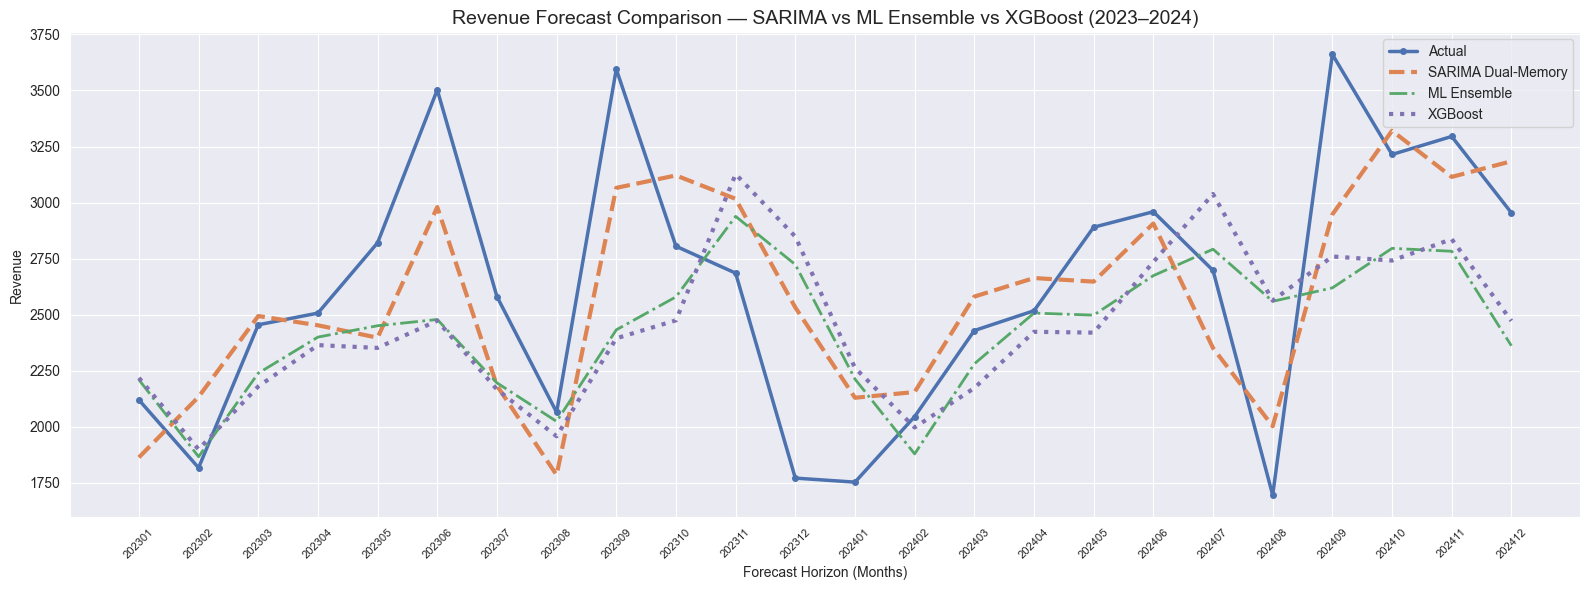

In [47]:
plt.figure(figsize=(16, 6))

plt.plot(compare_df.index, compare_df['Revenue'],
         label='Actual', linewidth=2.5, marker='o', markersize=4, color=palette[0])
plt.plot(compare_df.index, compare_df['SARIMA'],
         label='SARIMA Dual-Memory', linewidth=3, linestyle='--', color=palette[1])
plt.plot(compare_df.index, compare_df['Ensemble'],
         label='ML Ensemble', linewidth=2, linestyle='-.', color=palette[2])
plt.plot(compare_df.index, compare_df['XGBoost'],
         label='XGBoost', linewidth=3, linestyle=':', color=palette[4])

plt.title('Revenue Forecast Comparison — SARIMA vs ML Ensemble vs XGBoost (2023–2024)', fontsize=14)
plt.xlabel('Forecast Horizon (Months)')
plt.ylabel('Revenue')
plt.xticks(compare_df.index, compare_df['datekey'].astype(str), rotation=45, fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Feature Importance — FP&A Driver Attribution

Feature importance translates the ML model into a **driver-level financial narrative**. The two gradient-boosted models provide native importance scores through distinct mechanisms:

- **Random Forest**: measures the **mean reduction in node impurity** (Gini) attributed to each feature across all trees and splits
- **XGBoost**: measures the **total gain** from splits on each feature across all boosting rounds — weighted by the number of training samples affected

The combined ranking reveals which operational drivers carry the most predictive information for revenue — directly linking the ML output to the FP&A decomposition logic of the Price-Volume-Mix bridge in Module 4.5.

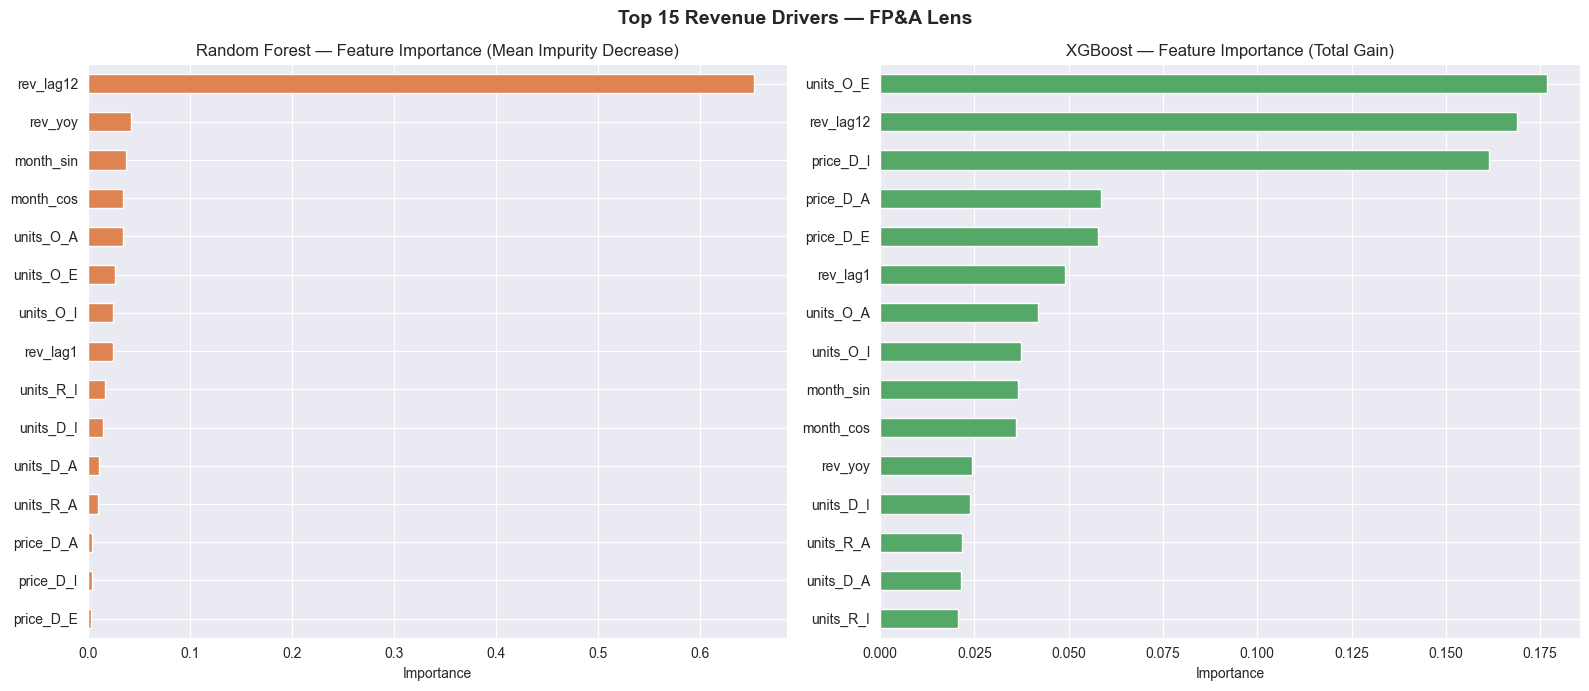

In [48]:
imp_rf  = pd.Series(rf_model.feature_importances_,  index=feature_cols, name='RandomForest')
imp_xgb = pd.Series(xgb_model.feature_importances_, index=feature_cols, name='XGBoost')

imp_df = pd.DataFrame({'RandomForest': imp_rf, 'XGBoost': imp_xgb})
imp_df['Mean'] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values('Mean', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

imp_df['RandomForest'].sort_values().plot(kind='barh', ax=axes[0], color=palette[1])
axes[0].set_title('Random Forest — Feature Importance (Mean Impurity Decrease)', fontsize=12)
axes[0].set_xlabel('Importance')

imp_df['XGBoost'].sort_values().plot(kind='barh', ax=axes[1], color=palette[2])
axes[1].set_title('XGBoost — Feature Importance (Total Gain)', fontsize=12)
axes[1].set_xlabel('Importance')

plt.suptitle('Top 15 Revenue Drivers — FP&A Lens', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Probabilistic Scenario Envelope

Following the same methodology as Module 4.2, a **Monte Carlo bootstrap simulation** quantifies uncertainty around the ML Ensemble deterministic forecast.

Residuals from the ML Ensemble on the **training set** are resampled with replacement and added to test-set predictions, generating 10,000 plausible revenue paths:

$$\tilde{y}_t^{(i)} = \hat{y}_{ensemble,t} + \epsilon^{(i)}_t, \quad \epsilon^{(i)} \sim \text{Bootstrap}(\hat{e}_{train})$$

Using training residuals (rather than an assumed parametric distribution) preserves the actual error structure of the model, including any asymmetry or fat tails from the stress period.

| Quantile | Scenario | FP&A Use |
|---|---|---|
| P10 | Stress | Contingency planning, liquidity stress test |
| P30 | Pessimistic | Downside operating bound |
| Base | Final Forecast | Budget baseline |
| P70 | Optimistic | Upside operating bound |

In [49]:
N_SIM = 10_000

# Out-of-fold residuals via TimeSeriesSplit (avoids in-sample optimism)
# Training residuals underestimate OOS error — OOF gives honest uncertainty
tscv = TimeSeriesSplit(n_splits=5)
oof_residuals = np.zeros(len(X_train))

_xgb_p = dict(n_estimators=300, learning_rate=0.05, max_depth=4,
              subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
_rf_p  = dict(n_estimators=300, max_depth=6, min_samples_leaf=3, random_state=42)
_lgb_p = dict(n_estimators=300, learning_rate=0.05, max_depth=4, num_leaves=15,
              subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)

for tr_idx, val_idx in tscv.split(X_train):
    X_tr,  y_tr  = X_train.iloc[tr_idx],  y_train.iloc[tr_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
    _x = xgb.XGBRegressor(**_xgb_p).fit(X_tr, y_tr)
    _r = RandomForestRegressor(**_rf_p).fit(X_tr, y_tr)
    _l = lgb.LGBMRegressor(**_lgb_p).fit(X_tr, y_tr)
    oof_pred = (_x.predict(X_val) + _r.predict(X_val) + _l.predict(X_val)) / 3
    oof_residuals[val_idx] = y_val.values - oof_pred

resid_train = oof_residuals

T = len(y_test)
sim_matrix = np.zeros((N_SIM, T))

rng = np.random.default_rng(42)
for i in range(N_SIM):
    eps = rng.choice(resid_train, size=T, replace=True)
    sim_matrix[i, :] = y_pred_ensemble + eps

p10 = np.percentile(sim_matrix, 10, axis=0)
p30 = np.percentile(sim_matrix, 30, axis=0)
p70 = np.percentile(sim_matrix, 70, axis=0)

mc_ml = ml_df[['datekey', 'Revenue', 'Ensemble']].copy()
mc_ml['Stress_P10']      = p10.round(2)
mc_ml['Pessimistic_P30'] = p30.round(2)
mc_ml['Optimistic_P70']  = p70.round(2)
mc_ml['Diff']            = (mc_ml['Revenue'] - mc_ml['Ensemble']).round(2)
mc_ml.head()

,datekey,Revenue,Ensemble,Stress_P10,Pessimistic_P30,Optimistic_P70,Diff
0,202301,2120.17,2210.34,1892.64,2194.92,2439.74,-90.17
1,202302,1817.49,1866.77,1549.07,1851.35,2096.16,-49.28
2,202303,2455.10,2239.29,1911.81,2223.87,2468.16,215.81
3,202304,2507.32,2400.25,2072.78,2378.68,2629.65,107.07
4,202305,2820.73,2450.92,2133.21,2435.50,2679.79,369.81


### 8.1 Annual Scenario Summary

In [50]:
mc_ml['year'] = mc_ml['datekey'].astype(str).str[:4].astype(int)

scenario_summary = mc_ml.groupby('year').agg(
    Revenue        =('Revenue',        'sum'),
    Ensemble       =('Ensemble',       'sum'),
    Stress_P10     =('Stress_P10',     'sum'),
    Pessimistic_P30=('Pessimistic_P30','sum'),
    Optimistic_P70 =('Optimistic_P70', 'sum')
).round(2)

scenario_summary['Diff'] = (scenario_summary['Revenue'] - scenario_summary['Ensemble']).round(2)
scenario_summary

,Revenue,Ensemble,Stress_P10,Pessimistic_P30,Optimistic_P70,Diff
year,,,,,,
2023,30726.94,28541.50,24689.99,28368.85,31297.97,2185.44
2024,32114.33,29965.59,26123.86,29903.92,32722.24,2148.74


## 9. Forecasting Governance Conclusion — Classical Statistics vs Machine Learning

This module compares the ML Ensemble from Section 4.6 with the SARIMA Dual-Memory model from Section 4.2 under a governed forecasting lens.

Under the corrected methodology, the ML model uses only lagged information: prior-month operational drivers, prior revenue, seasonal features, and lagged year-over-year revenue growth. This removes contemporaneous leakage from price, volume, and revenue-derived features.

### Methodological Interpretation

The ML Ensemble is evaluated as a **rolling one-step-ahead forecast**. At each monthly prediction point, prior-month actuals are assumed to be available. This is realistic for monthly FP&A forecasting cycles, but it is not the same as producing a fully fixed 24-month forecast from December 2022.

| Dimension | SARIMA Dual-Memory | ML Ensemble |
|---|---:|---:|
| Forecast design | Univariate time-series model | Driver-based rolling ML model |
| Information used | Historical revenue only | Lagged revenue + lagged operational drivers |
| Monthly accuracy | Stronger | Weaker after leakage correction |
| Annual accuracy | Strong | Comparable, but less stable |
| Interpretability | High | Medium-low |
| Governance | Native | Requires additional explanation |
| Feature dependency | None | Requires prior-month driver data |
| CFO explainability | Straightforward | Improved with SHAP |

### Conclusion

After removing leakage, the SARIMA Dual-Memory model outperforms the ML Ensemble on monthly accuracy. This result is statistically coherent: the original ML advantage came largely from using contemporaneous price and volume variables, which are closely tied to the revenue calculation itself.

The weaker ML performance does not invalidate the model. Rather, it clarifies its proper role. In this setup, the ML Ensemble is best used as a **complementary FP&A layer**: a driver-attribution engine, sensitivity tool, and quantitative stress-test framework. SARIMA remains the stronger governed baseline for standalone revenue forecasting.

This conclusion is consistent with forecasting practice: parsimonious statistical models often outperform high-dimensional ML models on short, structured monthly time series, especially when ML cannot use contemporaneous business drivers.

Together, Modules 4.2 and 4.6 show that robust FP&A forecasting is not a choice between statistics and machine learning. The strongest governance framework uses both: SARIMA for explainable baseline forecasting, and ML for driver interpretation, scenario analysis, and business diagnostics.

**SHAP** (SHapley Additive exPlanations) can be added to improve ML explainability by quantifying each feature's contribution to individual predictions.
